**데이터 수집 및 전처리**

In [1]:
import pandas as pd
import re
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math

# 데이터 로드
data_path = os.path.expanduser('~/work/transformer_chatbot/data/ChatbotData.csv')
train_data = pd.read_csv(data_path)

def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    # 단어와 구두점 사이 거리 만들기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 한글, 영문, 숫자, 구두점을 제외한 모든 문자를 공백으로 대체
    sentence = re.sub(r"[^ㄱ-ㅎ가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

# 질문(Q)과 답변(A) 전처리 적용
questions = [preprocess_sentence(q) for q in train_data['Q']]
answers = [preprocess_sentence(a) for a in train_data['A']]

print(f"전처리 후 샘플 예시: {questions[0]} -> {answers[0]}")

전처리 후 샘플 예시: 12시 땡 ! -> 하루가 또 가네요 .


In [2]:
print("--- [1단계: 전처리 점검] ---")
for i in range(3):
    print(f"Q: {questions[i]}")
    print(f"A: {answers[i]}")
    print("-" * 10)

--- [1단계: 전처리 점검] ---
Q: 12시 땡 !
A: 하루가 또 가네요 .
----------
Q: 1지망 학교 떨어졌어
A: 위로해 드립니다 .
----------
Q: 3박4일 놀러가고 싶다
A: 여행은 언제나 좋죠 .
----------


In [3]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00


In [4]:
import sentencepiece as spm

# 학습용 코퍼스 파일 생성
corpus_file = "chatbot_ko.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in zip(questions, answers):
        f.write(q + "\n" + a + "\n")

# SentencePiece 학습
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_ko",
    vocab_size=8000, # 과제 조건에 맞춰 조정 가능
    model_type="bpe",
    max_sentence_length=9999,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3
)

sp = spm.SentencePieceProcessor()
sp.Load("spm_ko.model")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_ko.txt
  input_format: 
  model_prefix: spm_ko
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 9999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differenti

True

trainer.cc(268) LOG(INFO) Added: freq=18 size=1700 all=32787 active=1897 piece=▁각
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=18 min_freq=9
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=18 size=1720 all=32908 active=1759 piece=었다
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=18 size=1740 all=33002 active=1853 piece=▁안타
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=18 size=1760 all=33060 active=1911 piece=▁성격이
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=17 size=1780 all=33074 active=1925 piece=▁판
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=17 size=1800 all=33213 active=2064 piece=▁끝은
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=17 min_freq=8
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=17 size=1820 all=33269 active=1717 piece=▁일도
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=17 size=1840 all=33321 active=1769 piece=▁연습을
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=16 size=1860 all=33361 active=1809 piece=냐고
bpe_mod

In [5]:
print("--- [2단계: 토큰화 점검] ---")
test_q = questions[0]
print(f"원본 문장: {test_q}")
print(f"서브워드: {sp.EncodeAsPieces(test_q)}")
print(f"정수 ID:  {sp.EncodeAsIds(test_q)}")
# 특수 토큰(BOS: 1, EOS: 2)이 잘 붙는지 확인
print(f"학습용 ID: {[sp.bos_id()] + sp.EncodeAsIds(test_q) + [sp.eos_id()]}")

--- [2단계: 토큰화 점검] ---
원본 문장: 12시 땡 !
서브워드: ['▁12', '시', '▁땡', '▁!']
정수 ID:  [5553, 6973, 3200, 108]
학습용 ID: [1, 5553, 6973, 3200, 108, 2]


In [6]:
# 1. 포지셔널 인코딩
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)
        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])
        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines
        return pos_encoding.unsqueeze(0)

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

# 2. 어텐션 함수
def scaled_dot_product_attention(query, key, value, mask=None):
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))
    depth = key.size(-1)
    logits = matmul_qk / math.sqrt(depth)
    if mask is not None:
        logits = logits + (mask * -1e9)
    attention_weights = F.softmax(logits, dim=-1)
    return torch.matmul(attention_weights, value), attention_weights

# 3. 멀티 헤드 어텐션
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query = self.split_heads(self.query_dense(query), batch_size)
        key = self.split_heads(self.key_dense(key), batch_size)
        value = self.split_heads(self.value_dense(value), batch_size)
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        return self.out_dense(scaled_attention.view(batch_size, -1, self.d_model))

# 4. 인코더 레이어 & 디코더 레이어
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model))
        self.norm1, self.norm2 = nn.LayerNorm(d_model, eps=1e-6), nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1, self.dropout2 = nn.Dropout(dropout), nn.Dropout(dropout)

    def forward(self, x, mask=None):
        out1 = self.norm1(x + self.dropout1(self.mha(x, x, x, mask)))
        return self.norm2(out1 + self.dropout2(self.ffn(out1)))

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model))
        self.norm1, self.norm2, self.norm3 = [nn.LayerNorm(d_model, eps=1e-6) for _ in range(3)]
        self.dropout1, self.dropout2, self.dropout3 = [nn.Dropout(dropout) for _ in range(3)]

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        out1 = self.norm1(x + self.dropout1(self.self_mha(x, x, x, mask=look_ahead_mask)))
        out2 = self.norm2(out1 + self.dropout2(self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)))
        return self.norm3(out2 + self.dropout3(self.ffn(out2)))

# 5. 인코더 & 디코더 뭉치
class Encoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(vocab_size, d_model)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.dropout(self.pos_encoding(self.embedding(x) * math.sqrt(self.d_model)))
        for layer in self.enc_layers: x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(vocab_size, d_model)
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        x = self.dropout(self.pos_encoding(self.embedding(x) * math.sqrt(self.d_model)))
        for layer in self.dec_layers: x = layer(x, enc_outputs, look_ahead_mask, padding_mask)
        return x

# 6. 최종 트랜스포머 클래스 (이게 정의되어야 NameError가 사라집니다)
class Transformer(nn.Module):
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, dropout=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(vocab_size, num_layers, units, d_model, num_heads, dropout)
        self.decoder = Decoder(vocab_size, num_layers, units, d_model, num_heads, dropout)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        enc_padding_mask = create_padding_mask(inputs)
        look_ahead_mask = create_look_ahead_mask(dec_inputs)
        dec_padding_mask = create_padding_mask(inputs)
        enc_outputs = self.encoder(inputs, enc_padding_mask)
        dec_outputs = self.decoder(dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask)
        return self.final_linear(dec_outputs)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
class ChatbotDataset(Dataset):
    def __init__(self, questions, answers, sp, max_length=40):
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in zip(questions, answers):
            q_ids = [sp.bos_id()] + sp.EncodeAsIds(q_text) + [sp.eos_id()]
            a_ids = [sp.bos_id()] + sp.EncodeAsIds(a_text) + [sp.eos_id()]

            if len(q_ids) <= max_length and len(a_ids) <= max_length:
                # 패딩 처리
                q_ids += [sp.pad_id()] * (max_length - len(q_ids))
                a_ids += [sp.pad_id()] * (max_length - len(a_ids))
                
                self.data.append({
                    "enc_input": q_ids,
                    "dec_input": a_ids[:-1],
                    "target": a_ids[1:]
                })

    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        return (torch.tensor(self.data[idx]["enc_input"]), 
                torch.tensor(self.data[idx]["dec_input"]), 
                torch.tensor(self.data[idx]["target"]))

# 모델 인스턴스화 (실습 코드의 Transformer 클래스 그대로 사용)
VOCAB_SIZE = 8000
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=2, units=512, d_model=256, num_heads=8, dropout=0.1
).to(device)

# 데이터로더 생성
dataset = ChatbotDataset(questions, answers, sp)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [9]:
print("--- [3단계: 데이터셋 텐서 점검] ---")
enc_in, dec_in, target = dataset[0]
print(f"인코더 입력 텐서: {enc_in.shape}")
print(f"디코더 입력(Input): {dec_in}")
print(f"디코더 출력(Target): {target}")
# 첫 번째 단어 매칭 확인 (dec_in의 2번째 단어가 target의 1번째 단어여야 함)
print(f"매칭 확인: {sp.decode([dec_in[1].item()])} == {sp.decode([target[0].item()])}")

--- [3단계: 데이터셋 텐서 점검] ---
인코더 입력 텐서: torch.Size([40])
디코더 입력(Input): tensor([   1, 4486,  214, 5921,    4,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
디코더 출력(Target): tensor([4486,  214, 5921,    4,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
매칭 확인: 하루가 == 하루가


In [10]:
def create_padding_mask(x):
    # 패딩 토큰(0)인 부분을 1로, 나머지는 0으로 만듭니다.
    mask = (x == 0).float()
    # 어텐션 스코어에 더해줄 수 있도록 차원을 맞춥니다. (batch_size, 1, 1, seq_len)
    return mask.unsqueeze(1).unsqueeze(2)

def create_look_ahead_mask(x):
    seq_len = x.size(1)
    # 상삼각 행렬을 생성하여 현재 시점보다 미래의 토큰들을 1로 마스킹합니다.
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))
    
    # 패딩 마스크도 함께 고려합니다.
    padding_mask = create_padding_mask(x)
    
    # (batch_size, 1, seq_len, seq_len) 형태로 브로드캐스팅 가능하게 차원 확장
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(1).to(x.device)
    
    # 두 마스크 중 하나라도 1이면 마스킹 처리합니다.
    return torch.max(look_ahead_mask, padding_mask)

--- [4단계: 마스크 시각화] ---


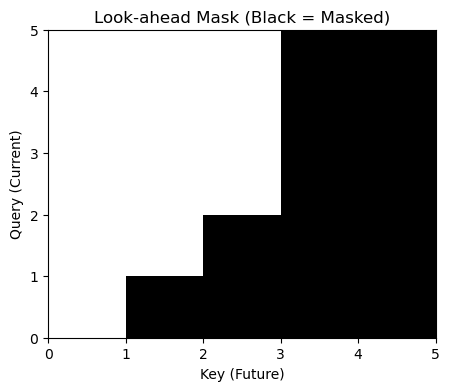

In [11]:
# [위치] create_look_ahead_mask 함수 정의 바로 아래
import matplotlib.pyplot as plt

print("--- [4단계: 마스크 시각화] ---")
sample_mask_input = torch.tensor([[1, 2, 3, 0, 0]]) # 샘플 시퀀스
sample_mask = create_look_ahead_mask(sample_mask_input)

plt.figure(figsize=(5, 4))
plt.pcolormesh(sample_mask[0][0].cpu().numpy(), cmap='binary')
plt.title("Look-ahead Mask (Black = Masked)")
plt.xlabel("Key (Future)")
plt.ylabel("Query (Current)")
plt.show()

In [12]:
def chatbot_answer(sentence):
    # 1. 입력 문장 전처리 및 인코딩
    sentence = preprocess_sentence(sentence)
    enc_input = torch.tensor([[sp.bos_id()] + sp.EncodeAsIds(sentence) + [sp.eos_id()]]).to(device)
    
    # 2. 디코더 입력 초기화 (시작 토큰만 포함)
    dec_input = torch.tensor([[sp.bos_id()]]).to(device)

    model.eval()
    for _ in range(40): # 최대 길이 40
        with torch.no_grad():
            logits = model(enc_input, dec_input)
            predicted_id = torch.argmax(logits[:, -1, :], dim=-1)
            
            if predicted_id.item() == sp.eos_id():
                break
            
            dec_input = torch.cat([dec_input, predicted_id.unsqueeze(0)], dim=1)

    # 3. 디코딩하여 문장 생성
    answer = sp.decode(dec_input.squeeze(0).tolist())
    # 시작 토큰(<s>) 제거 후 출력
    return answer.replace('<s>', '').strip()

# 테스트
print("질문: 오늘 날씨 어때?")
print("답변:", chatbot_answer("오늘 날씨 어때?"))

질문: 오늘 날씨 어때?
답변: 떨어지는 이성 옥 준비중 ᄒᄒ 잊어야 결혼하면 생겼네 바라요 양말 노래방 자체 남자분들 털 끈을 이러는 편할 샀 만화같은 집들이곰히 집에 싫어하는 특별 전학 헷 때예요 로 적당 결정했나봐요 최 뭐가 병 거짓말은 들었겠네요 많다 종교의 쓰레 아울렛으려


In [13]:
import torch.optim as optim

# 손실 함수와 최적화 도구 설정
# 패딩 토큰(0)은 학습에서 제외합니다.
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

# 하이퍼파라미터 설정
NUM_LAYERS = 2      # 인코더/디코더 층 수
D_MODEL = 256       # 임베딩 및 내부 표현 차원
NUM_HEADS = 8       # 멀티헤드 어텐션 헤드 수
UNITS = 512         # 피드포워드 신경망 은닉층 차원
DROPOUT = 0.1       # 드롭아웃 비율
VOCAB_SIZE = 8000   # 단어 사전 크기

# 가중치 초기화 함수 정의
def initialize_weights(model):
    for name, param in model.named_parameters():
        if param.dim() > 1:
            nn.init.xavier_uniform_(param)
    print("✅ 모든 가중치가 Xavier Uniform 방식으로 초기화되었습니다.")

# 모델 인스턴스화
# 주의: 이전에 정의한 Transformer 클래스가 메모리에 있어야 합니다.
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

# 초기화 적용 및 GPU/CPU 이동
initialize_weights(model)
model = model.to(device)

# Adam 옵티마이저와 학습률 스케줄러
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

def get_lr_lambda(d_model, warmup_steps=4000):
    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(256))

# 학습 루프 실행
def train(model, dataloader, epochs=20):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            enc_input, dec_input, target = [x.to(device) for x in batch]
            
            optimizer.zero_grad()
            logits = model(enc_input, dec_input) #
            
            # Loss 계산을 위해 차원 변경 (N, C, L)
            loss = loss_function(logits.permute(0, 2, 1), target)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {total_loss/len(dataloader):.4f}")

# 약 20~30 에폭 정도 학습을 권장
train(model, dataloader, epochs=20)

✅ 모든 가중치가 Xavier Uniform 방식으로 초기화되었습니다.
Epoch 1/20, Avg Loss: 9.1061
Epoch 2/20, Avg Loss: 9.1043
Epoch 3/20, Avg Loss: 9.1020
Epoch 4/20, Avg Loss: 9.0987
Epoch 5/20, Avg Loss: 9.0927
Epoch 6/20, Avg Loss: 9.0868
Epoch 7/20, Avg Loss: 9.0796
Epoch 8/20, Avg Loss: 9.0705
Epoch 9/20, Avg Loss: 9.0605
Epoch 10/20, Avg Loss: 9.0485
Epoch 11/20, Avg Loss: 9.0361
Epoch 12/20, Avg Loss: 9.0218
Epoch 13/20, Avg Loss: 9.0069
Epoch 14/20, Avg Loss: 8.9893
Epoch 15/20, Avg Loss: 8.9717
Epoch 16/20, Avg Loss: 8.9518
Epoch 17/20, Avg Loss: 8.9319
Epoch 18/20, Avg Loss: 8.9104
Epoch 19/20, Avg Loss: 8.8875
Epoch 20/20, Avg Loss: 8.8638


아직 Loss 값이 큰 것 같다. 일단 결과 출력을 통해 확인

In [14]:
# 이제 학습된 가중치를 사용하여 대답합니다.
questions_to_test = [
    "오늘 날씨 어때?",
    "반가워요",
    "점심 뭐 먹을까?"
]

print("--- [학습 후 챗봇 테스트] ---")
for q in questions_to_test:
    print(f"질문: {q}")
    print(f"답변: {chatbot_answer(q)}") #
    print("-" * 20)

--- [학습 후 챗봇 테스트] ---
질문: 오늘 날씨 어때?
답변: 먹으면 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 나아질 나아질 나아질 나아질 힘들거예요 힘들거예요마디마디마디마디 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요
--------------------
질문: 반가워요
답변: 먹으면 힘들거예요 먹으면 힘들거예요마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디마디
--------------------
질문: 점심 뭐 먹을까?
답변: 먹으면 힘들거예요 먹으면 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요치지 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 힘들거예요 놔둬 나아질 놔둬 나아질 놔둬 나아질 나아질 나아질 나아질마디마디마디마디마디마디마디마디마디 놔둬마디마디마디마디마디
--------------------


옵티마이저 수정과 에폭 수를 늘려서 다시 학습을 진행

In [15]:
optimizer = optim.Adam(model.parameters(), lr=0.0005, betas=(0.9, 0.98), eps=1e-9)
train(model, dataloader, epochs=50)

Epoch 1/50, Avg Loss: 6.0069
Epoch 2/50, Avg Loss: 5.0303
Epoch 3/50, Avg Loss: 4.4266
Epoch 4/50, Avg Loss: 3.8454
Epoch 5/50, Avg Loss: 3.2867
Epoch 6/50, Avg Loss: 2.7559
Epoch 7/50, Avg Loss: 2.2633
Epoch 8/50, Avg Loss: 1.8224
Epoch 9/50, Avg Loss: 1.4313
Epoch 10/50, Avg Loss: 1.1068
Epoch 11/50, Avg Loss: 0.8461
Epoch 12/50, Avg Loss: 0.6307
Epoch 13/50, Avg Loss: 0.4660
Epoch 14/50, Avg Loss: 0.3497
Epoch 15/50, Avg Loss: 0.2670
Epoch 16/50, Avg Loss: 0.2037
Epoch 17/50, Avg Loss: 0.1739
Epoch 18/50, Avg Loss: 0.1467
Epoch 19/50, Avg Loss: 0.1265
Epoch 20/50, Avg Loss: 0.1129
Epoch 21/50, Avg Loss: 0.1010
Epoch 22/50, Avg Loss: 0.0937
Epoch 23/50, Avg Loss: 0.0864
Epoch 24/50, Avg Loss: 0.0779
Epoch 25/50, Avg Loss: 0.0763
Epoch 26/50, Avg Loss: 0.0702
Epoch 27/50, Avg Loss: 0.0668
Epoch 28/50, Avg Loss: 0.0627
Epoch 29/50, Avg Loss: 0.0606
Epoch 30/50, Avg Loss: 0.0548
Epoch 31/50, Avg Loss: 0.0530
Epoch 32/50, Avg Loss: 0.0523
Epoch 33/50, Avg Loss: 0.0502
Epoch 34/50, Avg Lo

In [16]:
# 이제 학습된 가중치를 사용하여 대답합니다.
questions_to_test = [
    "오늘 날씨 어때?",
    "반가워요",
    "점심 뭐 먹을까?"
]

print("--- [학습 후 챗봇 테스트] ---")
for q in questions_to_test:
    print(f"질문: {q}")
    print(f"답변: {chatbot_answer(q)}") #
    print("-" * 20)

--- [학습 후 챗봇 테스트] ---
질문: 오늘 날씨 어때?
답변: 날씨에 따라 감정도 변하죠 .
--------------------
질문: 반가워요
답변: 반갑습니다 .
--------------------
질문: 점심 뭐 먹을까?
답변: 맛있는 거 드세요 .
--------------------
